# 04 — Model Evaluation

Evaluate the trained SurfaceAlpha model across walk-forward folds.
Covers: volatility forecast metrics, regime classification, tail-risk detection,
per-regime breakdown, Diebold-Mariano tests vs baselines, and model architecture analysis.

**Prerequisites:** Run `make train` and `make evaluate`, or at minimum have
`runs/liquid_core_v5/outputs/predictions/` populated.

In [3]:
import sys
import os
from pathlib import Path
if Path(os.getcwd()).name == 'notebooks':
    os.chdir('..')
sys.path.append(os.path.abspath('src'))
import warnings
warnings.filterwarnings('ignore')

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

from volregime.utils.config import load_config
from volregime.models.full_model import SurfaceAlphaModel

cfg = load_config()
# Change to V4 dir: Path('runs/liquid_core_v4/outputs') for V4
output_dir = Path('runs/liquid_core_v5/outputs')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"output_dir exists: {output_dir.exists()}")

Device: cpu
output_dir exists: True


## 1. Model Architecture Summary

In [4]:
model = SurfaceAlphaModel(cfg)
param_counts = model.count_parameters()

print("Parameter counts:")
for name, count in param_counts.items():
    print(f"  {name:>20s}: {count:>10,}")

# Verify forward pass with dummy data using correct dimensions from config
returns_dim     = cfg['model']['returns_encoder']['input_dim']          # 6
vol_history_dim = cfg['model']['context_encoder']['vol_history_dim']    # 11
macro_dim       = cfg['model']['context_encoder']['macro_dim']          # 6 for V5, 3 for V4

with torch.no_grad():
    dummy_out = model(
        surface=torch.randn(2, 6, 12, 20),
        returns=torch.randn(2, 60, returns_dim),
        vol_history=torch.randn(2, vol_history_dim),
        market_state=torch.randn(2, macro_dim),
    )
print(f"\nForward pass outputs:")
for k, v in dummy_out.items():
    print(f"  {k}: {v.shape}")

Parameter counts:
       surface_encoder:    408,960
       returns_encoder:    110,400
       context_encoder:      4,834
                fusion:     45,312
              vol_head:     16,641
             tail_head:      6,273
           regime_head:     16,966
            regime_moe:     31,302
                 total:    640,688

Forward pass outputs:
  rv_forecast: torch.Size([2])
  tail_prob: torch.Size([2])
  regime_logits: torch.Size([2, 6])
  regime_probs: torch.Size([2, 6])
  expert_preds: torch.Size([2, 6])


## 2. Load Walk-Forward Predictions

In [5]:
pred_dir = output_dir / 'predictions'
pred_files = sorted(pred_dir.glob('fold_*_test_preds.parquet')) if pred_dir.exists() else []
print(f"Found {len(pred_files)} fold prediction files")

if pred_files:
    all_preds = []
    for f in pred_files:
        df = pd.read_parquet(f)
        fold_num = int(f.stem.split('_')[1])
        df['fold'] = fold_num
        all_preds.append(df)
        print(f"  Fold {fold_num}: {len(df)} predictions, dates {df['date'].min()} -> {df['date'].max()}")

    preds_df = pd.concat(all_preds, ignore_index=True)
    preds_df['date'] = pd.to_datetime(preds_df['date'])
    print(f"\nTotal: {len(preds_df)} test predictions across {preds_df['fold'].nunique()} folds")
    print(f"Columns: {list(preds_df.columns)}")
    print(preds_df.head())
else:
    print("No predictions found. Run `make train` first.")

Found 28 fold prediction files
  Fold 0: 441 predictions, dates 2018-04-12 -> 2018-07-11
  Fold 10: 567 predictions, dates 2020-10-15 -> 2021-01-14
  Fold 11: 567 predictions, dates 2021-01-15 -> 2021-04-16
  Fold 12: 565 predictions, dates 2021-04-19 -> 2021-07-16
  Fold 13: 564 predictions, dates 2021-07-19 -> 2021-10-14
  Fold 14: 565 predictions, dates 2021-10-15 -> 2022-01-13
  Fold 15: 567 predictions, dates 2022-01-14 -> 2022-04-14
  Fold 16: 623 predictions, dates 2022-04-18 -> 2022-07-18
  Fold 17: 756 predictions, dates 2022-07-19 -> 2022-10-14
  Fold 18: 756 predictions, dates 2022-10-17 -> 2023-01-17
  Fold 19: 756 predictions, dates 2023-01-18 -> 2023-04-18
  Fold 1: 441 predictions, dates 2018-07-12 -> 2018-10-09
  Fold 20: 756 predictions, dates 2023-04-19 -> 2023-07-19
  Fold 21: 756 predictions, dates 2023-07-20 -> 2023-10-17
  Fold 22: 755 predictions, dates 2023-10-18 -> 2024-01-18
  Fold 23: 756 predictions, dates 2024-01-19 -> 2024-04-18
  Fold 24: 789 predictions,

## 3. Volatility Forecast Metrics

In [6]:
from volregime.evaluation.forecast_metrics import compute_vol_metrics, compute_per_regime_vol_metrics

if 'preds_df' in dir():
    # Correct column names: rv_pred, target_rv, target_regime, target_tail
    log_rv_pred = preds_df['rv_pred'].values
    log_rv_true = preds_df['target_rv'].values

    vol_metrics = compute_vol_metrics(log_rv_pred, log_rv_true)
    print("Overall Volatility Forecast Metrics:")
    for k, v in vol_metrics.items():
        print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

    # Per-fold metrics
    fold_metrics = []
    for fold in sorted(preds_df['fold'].unique()):
        mask = preds_df['fold'] == fold
        fm = compute_vol_metrics(log_rv_pred[mask], log_rv_true[mask])
        fm['fold'] = fold
        fold_metrics.append(fm)

    fold_df = pd.DataFrame(fold_metrics).set_index('fold')
    disp = [c for c in ['qlike', 'r2', 'rmse', 'mape', 'bias'] if c in fold_df.columns]
    print("\nPer-fold metrics:")
    print(fold_df[disp].round(4).to_string())

Overall Volatility Forecast Metrics:
  qlike: -3.6484
  ql: 0.1539
  mape: 0.2682
  r2: 0.3191
  bias: -0.0116
  rmse: 0.0417
  n: 17211

Per-fold metrics:
       qlike      r2    rmse    mape    bias
fold                                        
0    -5.2132 -0.0471  0.0129  0.3185  0.0083
1    -4.7942 -0.0853  0.0230  0.4290 -0.0014
2    -3.5255 -0.8798  0.0304  0.3123 -0.0219
3    -5.1156 -0.3864  0.0167  0.3233  0.0099
4    -4.8226 -0.4666  0.0154  0.2545 -0.0016
5    -4.3308 -0.7993  0.0205  0.2679 -0.0102
6    -5.4197  0.1660  0.0134  0.3018  0.0030
7     7.9628 -1.9147  0.1595  0.5996 -0.1303
8    -3.5183  0.3131  0.0325  0.3183  0.0030
9    -3.1420 -0.3203  0.0465  0.3239 -0.0014
10   -2.8433 -0.2952  0.0521  0.3878 -0.0146
11   -3.7767  0.1511  0.0422  0.2723 -0.0049
12   -4.5945  0.5305  0.0168  0.2472  0.0060
13   -4.7101  0.6217  0.0163  0.1859 -0.0007
14   -3.8086  0.5434  0.0300  0.2650 -0.0161
15   -3.2143 -0.0176  0.0367  0.2971 -0.0159
16   -3.3244  0.4375  0.0311  0.17

In [7]:
# Per-regime breakdown using target_regime column
if 'preds_df' in dir() and 'target_regime' in preds_df.columns:
    regime_true = preds_df['target_regime'].values.astype(int)
    regime_metrics = compute_per_regime_vol_metrics(
        log_rv_pred, log_rv_true, regime_true
    )

    regime_df = pd.DataFrame(regime_metrics).T
    display_cols = [c for c in ['n', 'qlike', 'r2', 'rmse', 'mape', 'bias'] if c in regime_df.columns]
    print("Volatility metrics by true regime:")
    print(regime_df[display_cols].round(4).to_string())

Volatility metrics by true regime:
                        n   qlike      r2    rmse    mape    bias
bull_quiet         5515.0 -4.1731  0.4467  0.0315  0.2577 -0.0086
bull_volatile      1186.0 -2.5176 -0.0378  0.0610  0.3121 -0.0209
bear_quiet         1163.0 -3.1839  0.3315  0.0509  0.2921 -0.0227
bear_volatile      1427.0 -1.6374 -0.3316  0.0733  0.2972 -0.0307
sideways_quiet     6588.0 -4.0656  0.4051  0.0312  0.2559 -0.0059
sideways_volatile  1332.0 -2.9794  0.0210  0.0471  0.2807 -0.0138


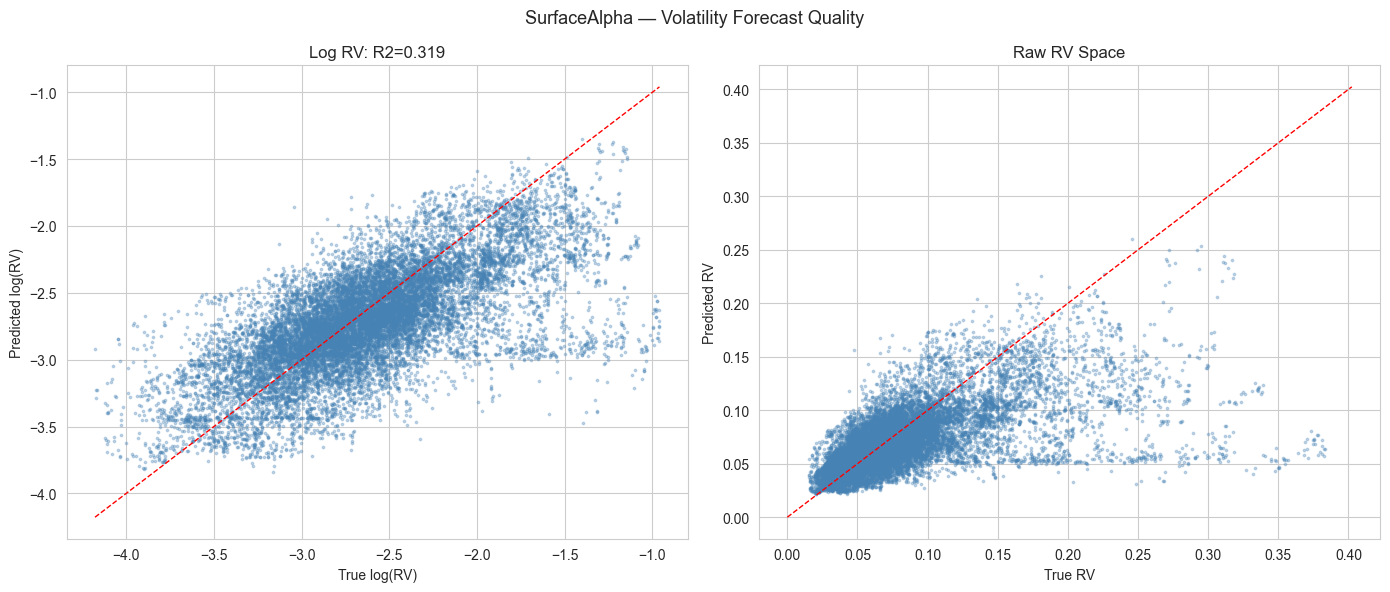

In [8]:
# Forecast scatter plot
if 'preds_df' in dir():
    rv_pred_raw = np.exp(log_rv_pred)
    rv_true_raw = np.exp(log_rv_true)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]
    ax.scatter(log_rv_true, log_rv_pred, s=3, alpha=0.3, color='steelblue')
    lims = [min(log_rv_true.min(), log_rv_pred.min()), max(log_rv_true.max(), log_rv_pred.max())]
    ax.plot(lims, lims, 'r--', lw=1)
    ax.set_xlabel('True log(RV)')
    ax.set_ylabel('Predicted log(RV)')
    r2_val = vol_metrics.get('r2', float('nan'))
    ax.set_title(f'Log RV: R2={r2_val:.3f}')

    ax = axes[1]
    ax.scatter(rv_true_raw, rv_pred_raw, s=3, alpha=0.3, color='steelblue')
    lims2 = [0, max(rv_true_raw.max(), rv_pred_raw.max()) * 1.05]
    ax.plot([0, lims2[1]], [0, lims2[1]], 'r--', lw=1)
    ax.set_xlabel('True RV')
    ax.set_ylabel('Predicted RV')
    ax.set_title('Raw RV Space')

    plt.suptitle('SurfaceAlpha — Volatility Forecast Quality', fontsize=13)
    plt.tight_layout()

## 4. Regime Classification

In [9]:
from volregime.evaluation.forecast_metrics import compute_classification_metrics
from sklearn.metrics import confusion_matrix

if 'preds_df' in dir() and 'target_regime' in preds_df.columns:
    regime_prob_cols = sorted([c for c in preds_df.columns if c.startswith('p_regime_')])
    regime_probs = preds_df[regime_prob_cols].values
    regime_true  = preds_df['target_regime'].values.astype(int)
    regime_pred  = regime_probs.argmax(axis=1)

    tail_prob = preds_df['tail_prob'].values if 'tail_prob' in preds_df.columns else np.zeros(len(preds_df))
    tail_true = preds_df['target_tail'].values.astype(int) if 'target_tail' in preds_df.columns else np.zeros(len(preds_df), dtype=int)

    cls_metrics = compute_classification_metrics(tail_prob, tail_true, regime_probs, regime_true)
    print("Classification Metrics:")
    for k, v in cls_metrics.items():
        if isinstance(v, float):
            print(f"  {k}: {v:.4f}")
        else:
            print(f"  {k}: {v}")

Classification Metrics:
  brier_score: 0.1423
  regime_accuracy: 0.3860
  regime_calibration: 0.0934
  tail_auc: 0.6597
  regime_acc_bull_quiet: 0.4598
  n_bull_quiet: 5515
  regime_acc_bull_volatile: 0.4384
  n_bull_volatile: 1186
  regime_acc_bear_quiet: 0.3293
  n_bear_quiet: 1163
  regime_acc_bear_volatile: 0.6307
  n_bear_volatile: 1427
  regime_acc_sideways_quiet: 0.3028
  n_sideways_quiet: 6588
  regime_acc_sideways_volatile: 0.2327
  n_sideways_volatile: 1332


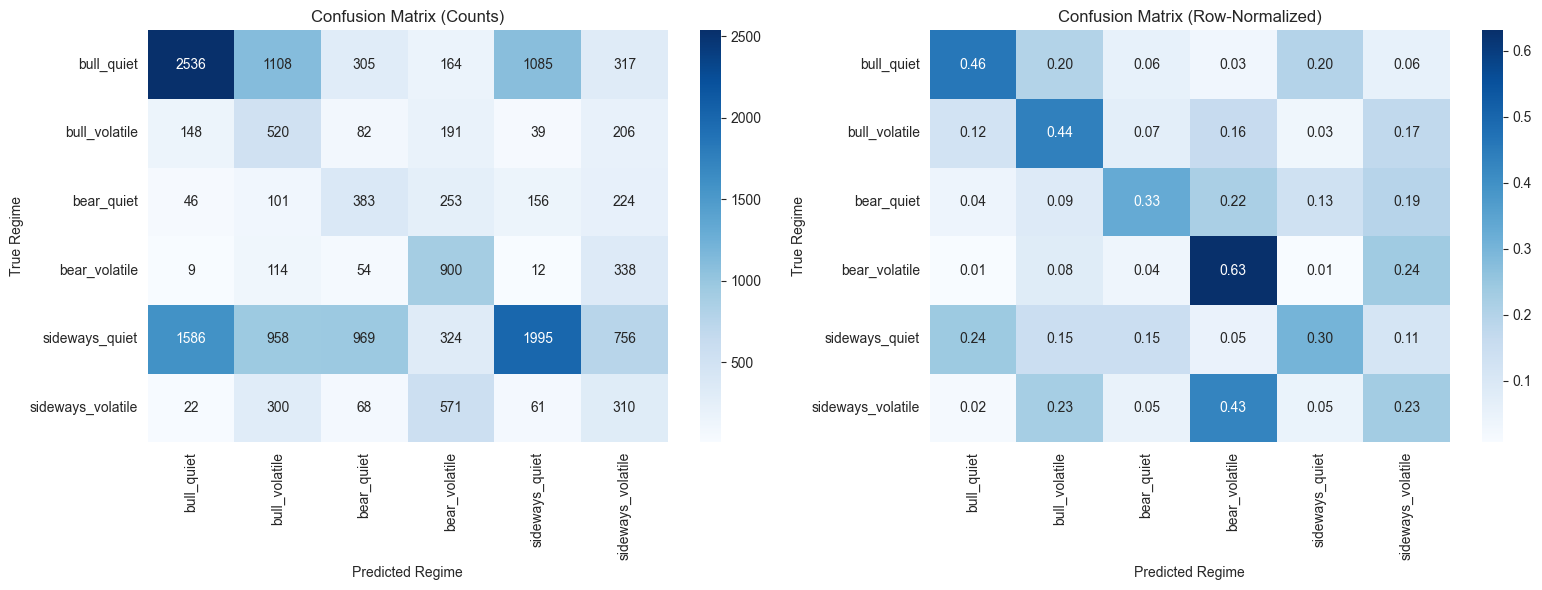

In [10]:
# Confusion matrix
if 'regime_pred' in dir():
    regime_names = ['bull_quiet', 'bull_volatile', 'bear_quiet', 'bear_volatile', 'sideways_quiet', 'sideways_volatile']
    cm      = confusion_matrix(regime_true, regime_pred, labels=range(6))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=regime_names, yticklabels=regime_names)
    axes[0].set_title('Confusion Matrix (Counts)')
    axes[0].set_ylabel('True Regime')
    axes[0].set_xlabel('Predicted Regime')

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
                xticklabels=regime_names, yticklabels=regime_names)
    axes[1].set_title('Confusion Matrix (Row-Normalized)')
    axes[1].set_ylabel('True Regime')
    axes[1].set_xlabel('Predicted Regime')

    plt.tight_layout()

## 5. Tail-Risk Detection

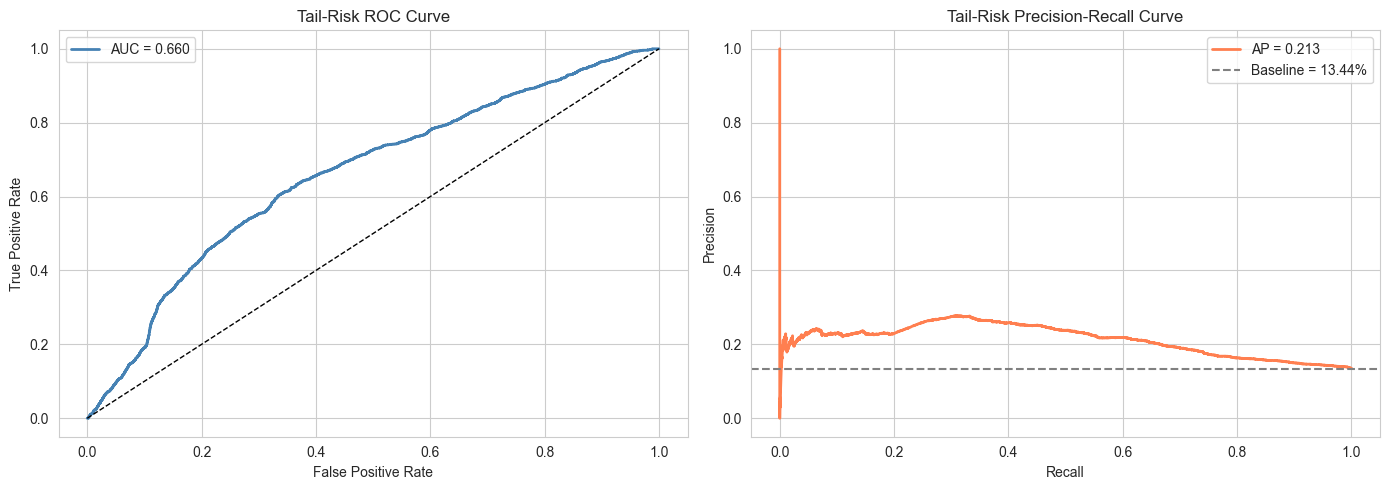

In [11]:
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score

if 'tail_prob' in dir() and tail_true.sum() > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    fpr, tpr, _ = roc_curve(tail_true, tail_prob)
    auc_val = cls_metrics.get('tail_auc', 0)
    axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc_val:.3f}')
    axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('Tail-Risk ROC Curve')
    axes[0].legend()

    prec, rec, _ = precision_recall_curve(tail_true, tail_prob)
    ap = average_precision_score(tail_true, tail_prob)
    baseline = tail_true.mean()
    axes[1].plot(rec, prec, color='coral', lw=2, label=f'AP = {ap:.3f}')
    axes[1].axhline(baseline, color='gray', ls='--', label=f'Baseline = {baseline:.2%}')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_title('Tail-Risk Precision-Recall Curve')
    axes[1].legend()

    plt.tight_layout()
else:
    print("Insufficient tail events for ROC/PR curves.")

## 6. Diebold-Mariano vs Baselines

In [12]:
from volregime.evaluation.stat_tests import compare_all_models

if 'preds_df' in dir():
    # Check if baseline predictions exist alongside SA predictions
    eval_dir = output_dir / 'evaluation'
    if eval_dir.exists():
        baseline_pred_files = sorted(eval_dir.glob('*_preds.parquet'))
        print(f"Found evaluation files: {[f.name for f in baseline_pred_files]}")

    predictions = {'surface_alpha': log_rv_pred}

    # Collect any baseline prediction columns stored in the fold parquets
    baseline_cols = [c for c in preds_df.columns if c.endswith('_pred') and c != 'rv_pred']
    for col in baseline_cols:
        name = col.replace('_pred', '')
        predictions[name] = preds_df[col].values

    if len(predictions) > 1:
        horizon_val = cfg['data']['targets']['forward_horizon']
        dm_results = compare_all_models(predictions, log_rv_true, h=horizon_val)

        print(f"\nDiebold-Mariano tests (SurfaceAlpha vs each baseline):")
        print(f"{'Baseline':>16s}  |  DM stat  |  p-value  |  SA better?")
        print("-" * 60)
        for name, res in dm_results.items():
            print(f"{name:>16s}  |  {res['dm_stat']:+7.3f}  |  {res['p_value']:.4f}    |  {'Yes' if res['sa_better'] else 'No'}")
    else:
        print("No baseline predictions found in fold files. Run baselines during training.")

Found evaluation files: []

Diebold-Mariano tests (SurfaceAlpha vs each baseline):
        Baseline  |  DM stat  |  p-value  |  SA better?
------------------------------------------------------------
          regime  |  -65.083  |  0.0000    |  Yes


## 7. Mincer-Zarnowitz for SurfaceAlpha

In [13]:
from volregime.evaluation.stat_tests import mincer_zarnowitz

if 'preds_df' in dir():
    mz = mincer_zarnowitz(log_rv_pred, log_rv_true)
    print("Mincer-Zarnowitz (SurfaceAlpha, log-RV space):")
    for k, v in mz.items():
        print(f"  {k}: {v}")

    print(f"\nInterpretation:")
    print(f"  Intercept {'close to 0' if abs(mz['intercept']) < 0.1 else 'biased'} ({mz['intercept']:.4f})")
    print(f"  Slope {'close to 1' if abs(mz['slope'] - 1) < 0.1 else 'not 1'} ({mz['slope']:.4f})")
    print(f"  F-test p={'not significant (efficient)' if mz['f_pvalue'] > 0.05 else 'significant (inefficient)'} ({mz['f_pvalue']:.4f})")

Mincer-Zarnowitz (SurfaceAlpha, log-RV space):
  intercept: -0.174578
  slope: 0.904624
  r2: 0.464017
  f_stat: 501.4072
  f_pvalue: 0.0
  n: 17211

Interpretation:
  Intercept biased (-0.1746)
  Slope close to 1 (0.9046)
  F-test p=significant (inefficient) (0.0000)


## 8. Forecast Time Series

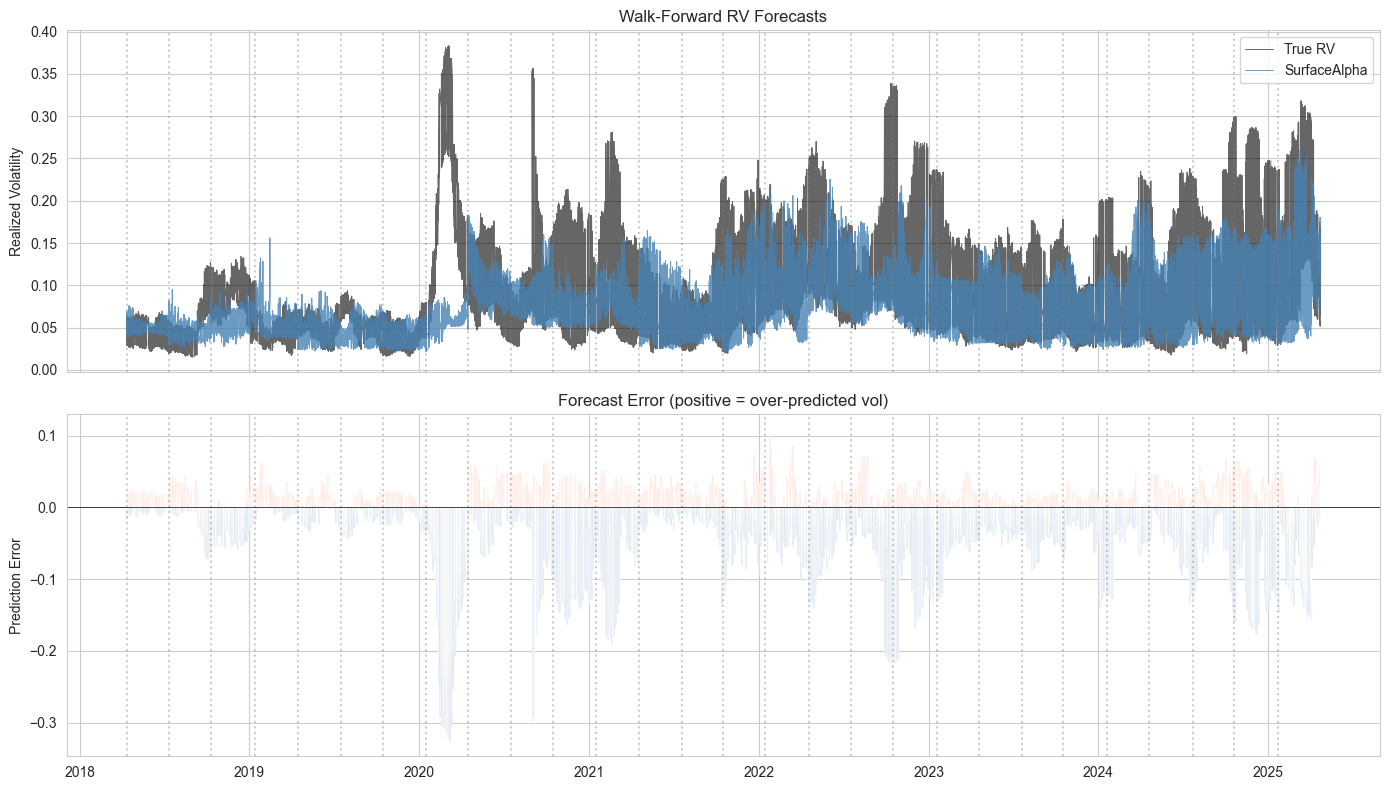

In [14]:
if 'preds_df' in dir():
    preds_sorted  = preds_df.sort_values('date').copy()
    dates_plot    = pd.to_datetime(preds_sorted['date'])
    rv_true_ts    = np.exp(preds_sorted['target_rv'].values)
    rv_pred_ts    = np.exp(preds_sorted['rv_pred'].values)

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    axes[0].plot(dates_plot, rv_true_ts, 'k-', lw=0.7, alpha=0.6, label='True RV')
    axes[0].plot(dates_plot, rv_pred_ts, '-', color='steelblue', lw=0.7, alpha=0.8, label='SurfaceAlpha')
    axes[0].set_ylabel('Realized Volatility')
    axes[0].set_title('Walk-Forward RV Forecasts')
    axes[0].legend()

    for fold in preds_sorted['fold'].unique():
        fold_start = pd.to_datetime(preds_sorted[preds_sorted['fold'] == fold]['date'].min())
        axes[0].axvline(fold_start, color='gray', ls=':', alpha=0.4)
        axes[1].axvline(fold_start, color='gray', ls=':', alpha=0.4)

    error = rv_pred_ts - rv_true_ts
    axes[1].bar(dates_plot, error, width=1,
                color=np.where(error > 0, 'coral', 'steelblue'), alpha=0.6)
    axes[1].axhline(0, color='k', lw=0.5)
    axes[1].set_ylabel('Prediction Error')
    axes[1].set_title('Forecast Error (positive = over-predicted vol)')

    plt.tight_layout()

## 9. MoE Expert Specialization

Mean expert std:   0.4641
Mean expert range: 1.3357
Pct with std > 0.05: 99.8%
Pct with std < 0.01 (collapse): 0.0%


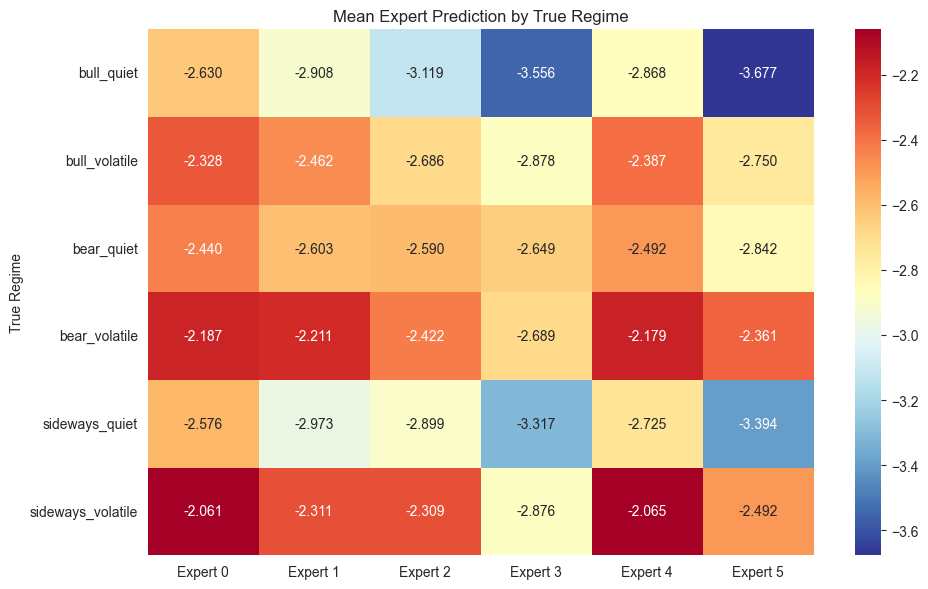

In [15]:
# Analyze expert predictions by regime
# Expert columns are expert_0, expert_1, ... (NOT expert_pred_0)
if 'preds_df' in dir():
    expert_cols = [f'expert_{k}' for k in range(6)]
    expert_cols = [c for c in expert_cols if c in preds_df.columns]

    if expert_cols and 'target_regime' in preds_df.columns:
        regime_names = ['bull_quiet', 'bull_volatile', 'bear_quiet',
                        'bear_volatile', 'sideways_quiet', 'sideways_volatile']
        expert_preds = preds_df[expert_cols].values
        regime_labels = preds_df['target_regime'].values.astype(int)

        # Mean expert prediction by true regime
        expert_by_regime = np.zeros((6, len(expert_cols)))
        for k in range(6):
            mask = regime_labels == k
            if mask.sum() > 0:
                expert_by_regime[k] = expert_preds[mask].mean(axis=0)

        fig, ax = plt.subplots(figsize=(10, 6))
        sns.heatmap(expert_by_regime, annot=True, fmt='.3f', cmap='RdYlBu_r',
                    xticklabels=[f'Expert {i}' for i in range(len(expert_cols))],
                    yticklabels=regime_names, ax=ax)
        ax.set_title('Mean Expert Prediction by True Regime')
        ax.set_ylabel('True Regime')
        plt.tight_layout()

        # Expert diversity
        expert_std   = expert_preds.std(axis=1)
        expert_range = expert_preds.max(axis=1) - expert_preds.min(axis=1)
        print(f"Mean expert std:   {expert_std.mean():.4f}")
        print(f"Mean expert range: {expert_range.mean():.4f}")
        print(f"Pct with std > 0.05: {(expert_std > 0.05).mean():.1%}")
        print(f"Pct with std < 0.01 (collapse): {(expert_std < 0.01).mean():.1%}")
    else:
        print("Expert columns (expert_0..5) or target_regime not found in prediction files.")